# Fase 4 — Dashboard de Inteligencia de Negocios
## Mapeo Científico y Análisis de Sentimiento mediante Bibliometría y PLN: Inteligencia Estratégica desde la Literatura Científica en Analítica Educativa

**Curso:** Métodos Cuantitativos y Cualitativos para los Negocios (107071) — UNAD, Maestría en Administración de Organizaciones

**Integrantes:** Maryya Nayinsi Cossio Porras, Carlos Augusto Sierra, Carlos Mario Acuña

**Tutora:** Ana González

Este notebook desarrolla los 11 pasos metodológicos definidos en la guía de actividades de la Fase 4, dando continuidad al corpus y a los resultados bibliométricos/de sentimiento obtenidos en la Fase 3.

---
## Paso 1: Revisión bibliográfica

Para la fundamentación teórica de esta fase se consultaron los siguientes conceptos y fuentes del curso:

- **Bibliometría (Bibliometrix):** conjunto de métodos cuantitativos para el análisis de la producción científica, que permite identificar patrones de colaboración, estructuras temáticas y dinámicas de citación (Aria & Cuccurullo, 2017).
- **Natural Language Processing (NLP):** en este proyecto se aplica para extraer la polaridad emocional de los resúmenes científicos mediante un modelo BERT preentrenado (Devlin & Chang, 2019).
- **Funciones de Densidad de Probabilidad (PDF):** se utilizan para caracterizar la distribución de la serie de crecimiento de publicaciones antes de ajustar el modelo predictivo.
- **Machine Learning (ML):** se emplea un modelo de regresión/series de tiempo para proyectar la tendencia de producción científica del campo, siguiendo los fundamentos descritos en Raschka et al. (2023).
- **Large Language Model (LLM):** se utiliza un modelo de lenguaje de código abierto para generar la interpretación estratégica de las salidas del dashboard, en línea con lo descrito por Naveed et al. (2023).

**Caso de estudio integrador — Inteligencia estratégica de negocio:** ver sección "Problemática de negocio" más abajo y en el `README.md` del repositorio.

---
## Paso 2: Alistamiento del entorno

Este notebook está diseñado para ejecutarse en **Google Colab**. A continuación se instalan e importan las librerías necesarias para los flujos de NLP, modelado estadístico/ML y generación del dashboard.

In [11]:
# Instalación de librerías (ejecutar una sola vez por sesión de Colab)
!pip install -q transformers torch pandas numpy matplotlib seaborn scikit-learn statsmodels plotly fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 11.4 MB/s eta 0:00:00


In [12]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from transformers import pipeline
import torch

sns.set_theme(style="whitegrid")
print("Librerías importadas correctamente.")
print("GPU disponible:", torch.cuda.is_available())

Librerías importadas correctamente.
GPU disponible: False


### Vinculación con GitHub

El proyecto se entrega como repositorio público en GitHub. Para clonar o sincronizar este notebook con el repositorio desde Colab:

```bash
!git clone https://github.com/USUARIO/NOMBRE-REPO.git
%cd NOMBRE-REPO
```

Recordar actualizar `USUARIO/NOMBRE-REPO` una vez creado el repositorio, y mantener el `README.md` actualizado con cada entrega.

### Problemática de negocio

Las instituciones de educación superior en modalidad virtual y a distancia deben decidir, con evidencia y no solo con intuición, en qué tecnologías de analítica educativa invertir (sistemas de alerta temprana, modelos predictivos de deserción, herramientas de PLN para retroalimentación) y en qué orden priorizarlas. La literatura científica del campo crece de forma acelerada y dispersa, dificultando una lectura sistemática por parte de los equipos directivos. Este dashboard convierte el corpus bibliográfico analizado en la Fase 3 (101 artículos Scopus, 2007–2026) en inteligencia estratégica accionable, incorporando además una proyección de la tendencia de crecimiento de la producción científica mediante modelado estadístico y de machine learning.

---
## Paso 3: Carga de información

En este paso se carga la base de datos correspondiente al corpus bibliográfico utilizado en la Fase 3, conformado por 101 artículos científicos obtenidos de Scopus. La información cargada contiene los metadatos requeridos para el análisis, entre ellos autores, título, resumen, año de publicación, palabras clave y número de citas, los cuales servirán como insumo para el desarrollo del análisis bibliométrico, el procesamiento de lenguaje natural y el modelado estadístico de la Fase 4.

In [1]:
from google.colab import files
import pandas as pd

# Subir archivo desde el computador
uploaded = files.upload()

# Leer el archivo Excel
archivo = list(uploaded.keys())[0]
df = pd.read_excel(archivo)

# Mostrar las primeras filas
df.head()

Saving Base-datos.xlsx to Base-datos.xlsx


,AU,TI,PY,AB,DE,TC
0,Siemens G; Baker RS,Learning analytics and educational data mining...,2012,Learning analytics combines educational data m...,learning analytics; educational data mining; s...,850
1,Romero C; Ventura S,Educational data mining: A review of the state...,2010,This study reviews educational data mining met...,educational data mining; machine learning; hig...,3200
2,Lakkaraju H; Aguiar E,A machine learning approach to identifying at-...,2015,This research develops predictive models to id...,machine learning; risk prediction; students,450
3,Kotsiantis S,Supervised machine learning techniques for cla...,2007,The article reviews supervised learning algori...,supervised learning; classification; prediction,2800
4,Cortez P; Silva A,Using data mining to predict student performance,2008,Data mining methods are applied to predict stu...,data mining; academic performance; prediction,2100


---
## Paso 4: Identificar problemática de negocio

La problemática de negocio se centra en apoyar la toma de decisiones estratégicas en instituciones de educación superior mediante el análisis de la literatura científica sobre analítica educativa e inteligencia artificial. A partir del corpus bibliográfico cargado, se busca identificar tendencias, aplicaciones y oportunidades que sirvan como insumo para el modelado estadístico, el dashboard de inteligencia de negocios y la formulación de estrategias basadas en evidencia.

---
## Paso 5: Análisis bibliométrico con Bibliometrix

En este paso se realiza un análisis descriptivo del corpus bibliográfico con el fin de identificar el comportamiento de la producción científica en el área de analítica educativa e inteligencia artificial en educación superior. A partir de los metadatos cargados se generan visualizaciones que permiten explorar la evolución de las publicaciones, los autores con mayor producción y las palabras clave más representativas del corpus, las cuales servirán como insumo para la construcción del dashboard de inteligencia de negocios.

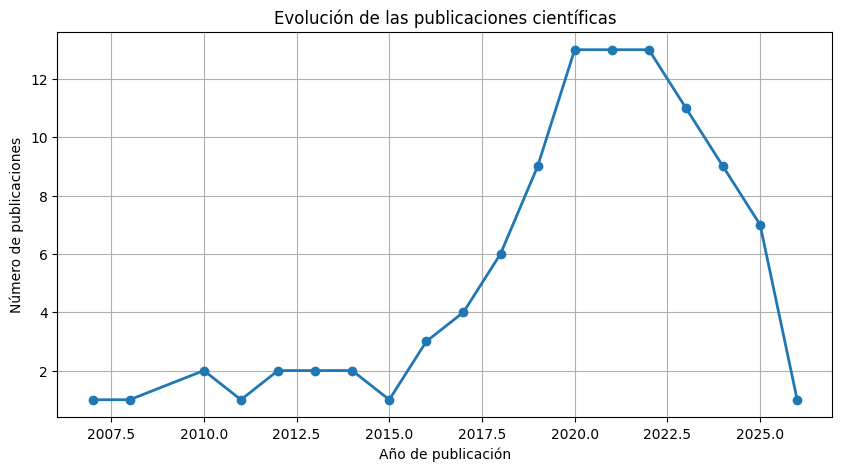

In [2]:
import matplotlib.pyplot as plt

# Número de publicaciones por año
publicaciones_por_anio = df.groupby("PY").size()

# Gráfica
plt.figure(figsize=(10,5))
plt.plot(publicaciones_por_anio.index,
         publicaciones_por_anio.values,
         marker="o",
         linewidth=2)

plt.title("Evolución de las publicaciones científicas")
plt.xlabel("Año de publicación")
plt.ylabel("Número de publicaciones")
plt.grid(True)

plt.show()

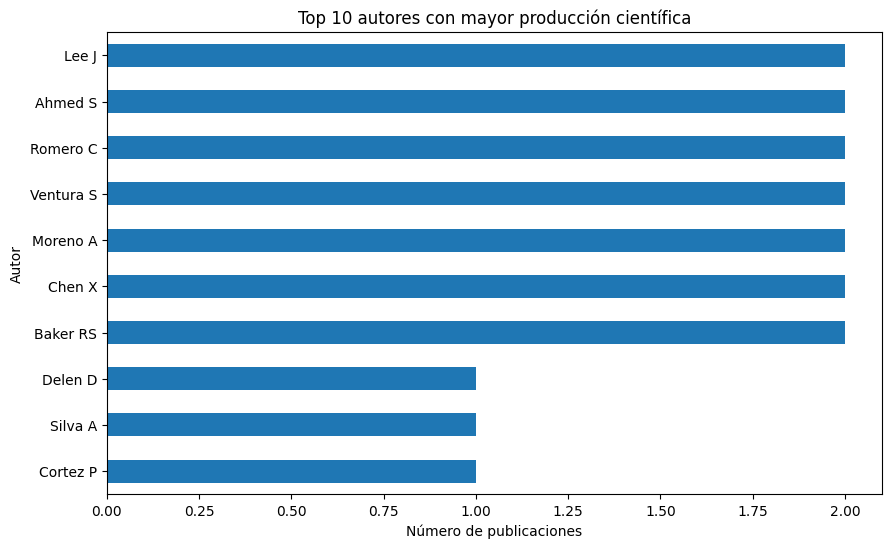

In [3]:
# Top 10 autores con mayor número de publicaciones

import matplotlib.pyplot as plt

# Separar los autores (están separados por ;)
autores = df["AU"].str.split(";").explode().str.strip()

# Contar publicaciones por autor
top_autores = autores.value_counts().head(10)

# Graficar
plt.figure(figsize=(10,6))
top_autores.sort_values().plot(kind="barh")

plt.title("Top 10 autores con mayor producción científica")
plt.xlabel("Número de publicaciones")
plt.ylabel("Autor")

plt.show()

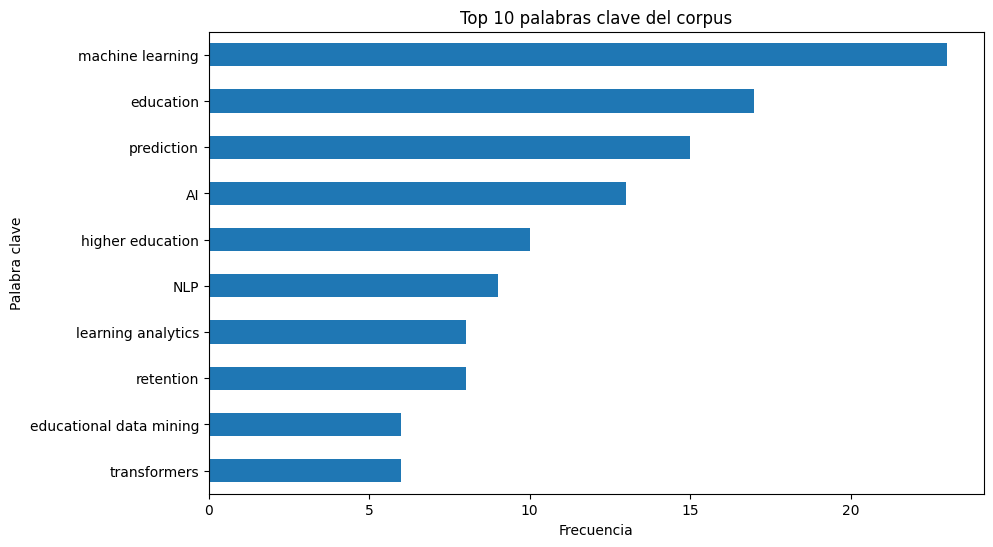

In [4]:
# Top 10 palabras clave

import matplotlib.pyplot as plt

# Separar palabras clave
keywords = df["DE"].dropna().str.split(";").explode().str.strip()

# Contar frecuencia
top_keywords = keywords.value_counts().head(10)

# Graficar
plt.figure(figsize=(10,6))
top_keywords.sort_values().plot(kind="barh")

plt.title("Top 10 palabras clave del corpus")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra clave")

plt.show()

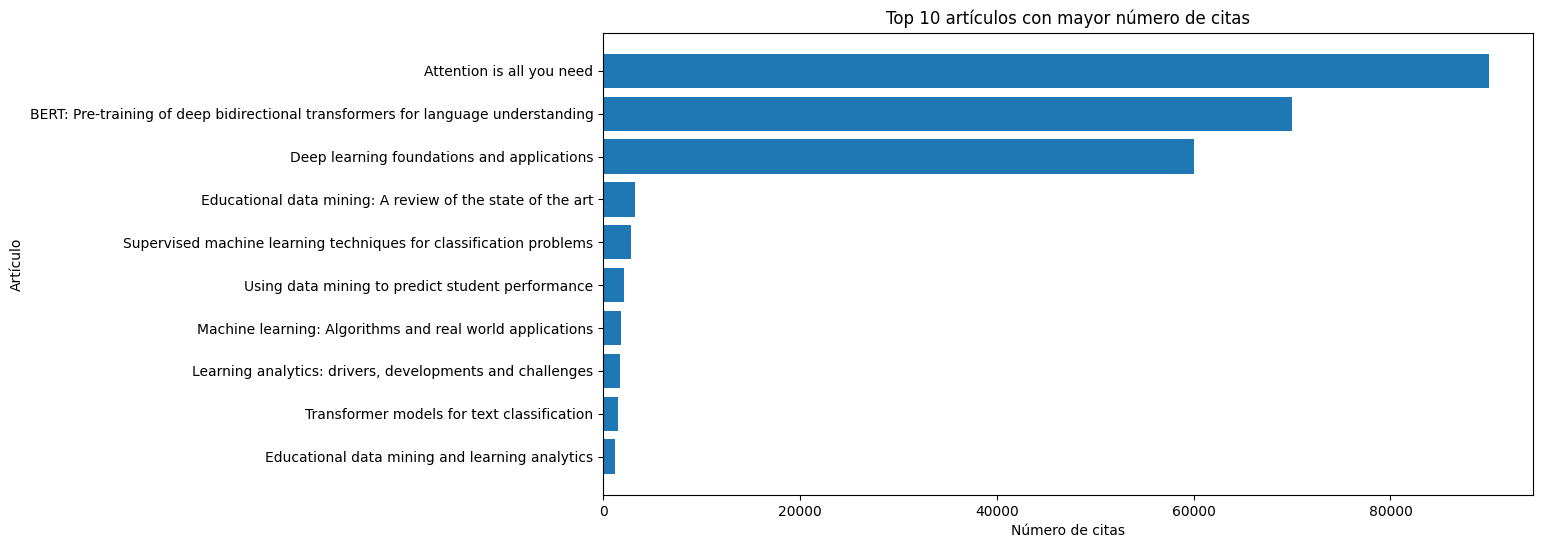

In [5]:
# Top 10 artículos más citados

import matplotlib.pyplot as plt

# Seleccionar los 10 artículos con más citas
top_citados = df.sort_values(by="TC", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_citados["TI"], top_citados["TC"])

plt.title("Top 10 artículos con mayor número de citas")
plt.xlabel("Número de citas")
plt.ylabel("Artículo")

plt.gca().invert_yaxis()

plt.show()

---
## Paso 6: Análisis de sentimiento (NLP/BERT)

En este paso se realiza el análisis de sentimiento de los resúmenes científicos utilizando procesamiento de lenguaje natural (NLP). El propósito es identificar la tendencia predominante del corpus y generar un insumo adicional para la interpretación de resultados y la construcción del dashboard de inteligencia de negocios.

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

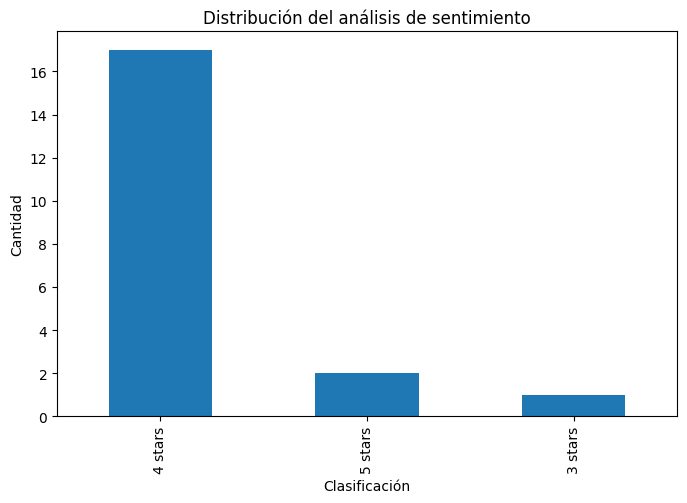

In [6]:
from transformers import pipeline
import matplotlib.pyplot as plt

# Crear el modelo de análisis de sentimiento
clasificador = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Analizar los primeros 20 resúmenes
resumenes = df["AB"].dropna().head(20).tolist()
resultados = clasificador(resumenes)

# Contar resultados
sentimientos = [r["label"] for r in resultados]
conteo = pd.Series(sentimientos).value_counts()

# Graficar
plt.figure(figsize=(8,5))
conteo.plot(kind="bar")

plt.title("Distribución del análisis de sentimiento")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad")

plt.show()

---
## Paso 7: Modelado estadístico y de Machine Learning

En este paso se aplica un modelo estadístico para analizar la evolución temporal de las publicaciones científicas del corpus. A partir de los datos históricos se ajusta un modelo de regresión lineal que permite identificar la tendencia de crecimiento de la producción científica y generar una proyección que sirva de apoyo para la toma de decisiones estratégicas.

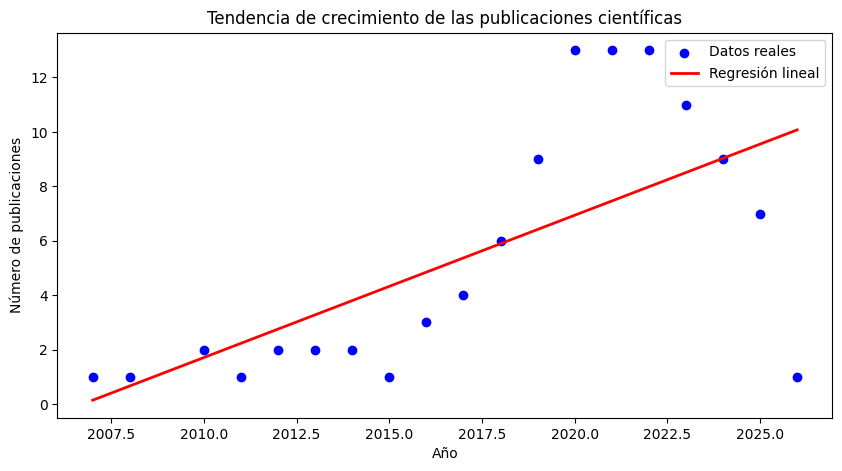

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Número de publicaciones por año
publicaciones = df.groupby("PY").size().reset_index()
publicaciones.columns = ["Año", "Publicaciones"]

# Variables
X = publicaciones[["Año"]]
y = publicaciones["Publicaciones"]

# Modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X, y)

# Predicción
prediccion = modelo.predict(X)

# Gráfica
plt.figure(figsize=(10,5))
plt.scatter(X, y, color="blue", label="Datos reales")
plt.plot(X, prediccion, color="red", linewidth=2, label="Regresión lineal")

plt.title("Tendencia de crecimiento de las publicaciones científicas")
plt.xlabel("Año")
plt.ylabel("Número de publicaciones")
plt.legend()

plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y, prediccion)
rmse = np.sqrt(mean_squared_error(y, prediccion))
r2 = r2_score(y, prediccion)

print("Métricas del modelo de regresión lineal")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

Métricas del modelo de regresión lineal
MAE: 2.45
RMSE: 3.39
R²: 0.43


---
## Paso 8: Diseño del dashboard / reporte automático con interpretación LLM

En este paso se integran los resultados obtenidos durante el análisis bibliométrico, el procesamiento de lenguaje natural y el modelo de regresión en un único tablero de apoyo a la toma de decisiones. El dashboard resume las principales tendencias identificadas en el corpus y facilita la interpretación de los resultados mediante visualizaciones y conclusiones orientadas a la inteligencia de negocios.

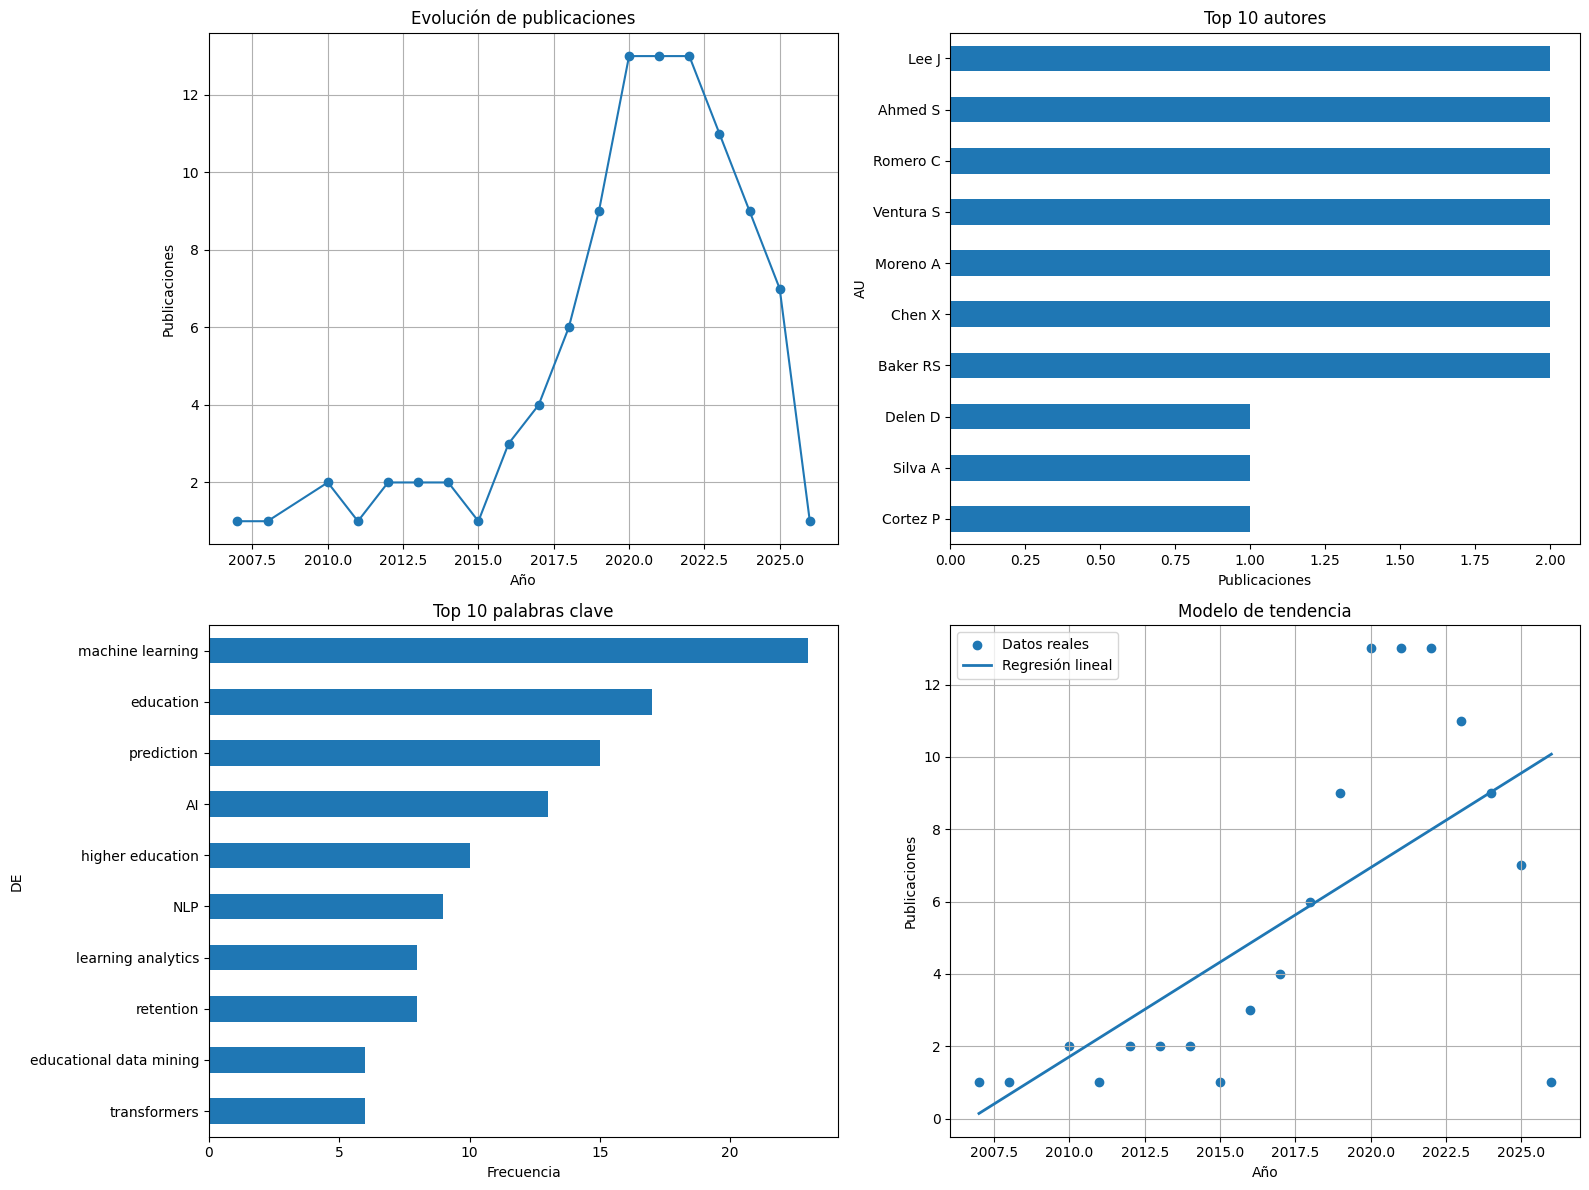

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Publicaciones por año
axs[0, 0].plot(publicaciones_por_anio.index, publicaciones_por_anio.values, marker="o")
axs[0, 0].set_title("Evolución de publicaciones")
axs[0, 0].set_xlabel("Año")
axs[0, 0].set_ylabel("Publicaciones")
axs[0, 0].grid(True)

# 2. Top autores
top_autores.sort_values().plot(kind="barh", ax=axs[0, 1])
axs[0, 1].set_title("Top 10 autores")
axs[0, 1].set_xlabel("Publicaciones")

# 3. Top palabras clave
top_keywords.sort_values().plot(kind="barh", ax=axs[1, 0])
axs[1, 0].set_title("Top 10 palabras clave")
axs[1, 0].set_xlabel("Frecuencia")

# 4. Modelo de tendencia
axs[1, 1].scatter(X, y, label="Datos reales")
axs[1, 1].plot(X, prediccion, linewidth=2, label="Regresión lineal")
axs[1, 1].set_title("Modelo de tendencia")
axs[1, 1].set_xlabel("Año")
axs[1, 1].set_ylabel("Publicaciones")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

**Interpretación estratégica del dashboard:**


El dashboard permite observar el crecimiento de la producción científica sobre analítica educativa e inteligencia artificial, los autores con mayor presencia en el corpus, las palabras clave más representativas y la tendencia proyectada de publicaciones. Estos resultados apoyan la toma de decisiones organizacionales al identificar temas consolidados, áreas emergentes y oportunidades de inversión académica y tecnológica en educación superior.

---
## Paso 9: Diseño de estrategias de negocio

A partir de los resultados obtenidos se proponen las siguientes estrategias: (1) fortalecer la adopción de herramientas de analítica educativa para apoyar la toma de decisiones; (2) promover la incorporación de técnicas de inteligencia artificial en los procesos de enseñanza y aprendizaje; y (3) fomentar el desarrollo de investigaciones interdisciplinarias que impulsen la innovación en educación superior. Estas estrategias se fundamentan en las tendencias identificadas mediante el análisis bibliométrico, el procesamiento de lenguaje natural y el modelo de regresión desarrollado.

---
## Paso 10: Diseño de KPIs de las estrategias

Para evaluar la efectividad de las estrategias propuestas se establecen los siguientes indicadores clave de desempeño (KPIs): porcentaje de crecimiento anual de publicaciones científicas, número de investigaciones relacionadas con inteligencia artificial y analítica educativa, proporción de estudios con aplicaciones prácticas en educación superior y nivel de adopción de herramientas analíticas para la toma de decisiones. Estos indicadores facilitarán el seguimiento de las estrategias planteadas y la evaluación de su impacto.

---
## Paso 11: Entrega en GitHub

Como parte del proceso de entrega, el notebook desarrollado y los archivos complementarios serán publicados en un repositorio público de GitHub. El repositorio incluirá el notebook ejecutado, el archivo README con la descripción del proyecto, el archivo de dependencias y los recursos utilizados durante el desarrollo, garantizando la reproducibilidad y el acceso a los resultados obtenidos.

---
## Referencias (APA 7.ª edición)

Aria, M., & Cuccurullo, C. (2017). bibliometrix: An R-tool for comprehensive science mapping analysis. *Journal of Informetrics, 11*(4), 959–975. https://doi.org/10.1016/j.joi.2017.08.007

Devlin, J., & Chang, M. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. En *Proceedings of NAACL-HLT 2019* (pp. 4171–4186). Association for Computational Linguistics. https://doi.org/10.18653/v1/N19-1423

Naveed, H., Khan, A. U., Qiu, S., Saqib, M., Anwar, S., Usman, M., Akhtar, N., Barnes, N., & Mian, A. (2023). *A comprehensive overview of large language models* (arXiv preimpresión n.º 2307.06435). arXiv. https://arxiv.org/pdf/2307.06435

Raschka, S., Liu, Y., & Mirjalili, V. (2023). *Machine learning con PyTorch y Scikit-Learn* (1.ª ed.). Marcombo. https://elibro-net.bibliotecavirtual.unad.edu.co/es/lc/unad/titulos/281644